<a href="https://colab.research.google.com/github/AdityaAgrawal08/Airline_Customer_Tweets_Analysis/blob/main/FDS_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries (run once in Colab)
!pip install nltk

Title

Sentiment Analysis and Classification of Airline Customer Tweets Using Text Mining

Objective

To analyze airline-related Twitter data and identify customer sentiment patterns using text mining techniques, visualization, and machine learning–based sentiment classification.

Import Libraries ->

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Dataset ->

In [ ]:
url="https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/refs/heads/master/Tweets.csv"

data = pd.read_csv(url)

data.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Basic Dataset Information ->

In [ ]:
print("Total Tweets:", len(data))

print("\nSentiment Counts:")
print(data['airline_sentiment'].value_counts())

Total Tweets: 14640

Sentiment Counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


Sentiment Distribution Graph ->

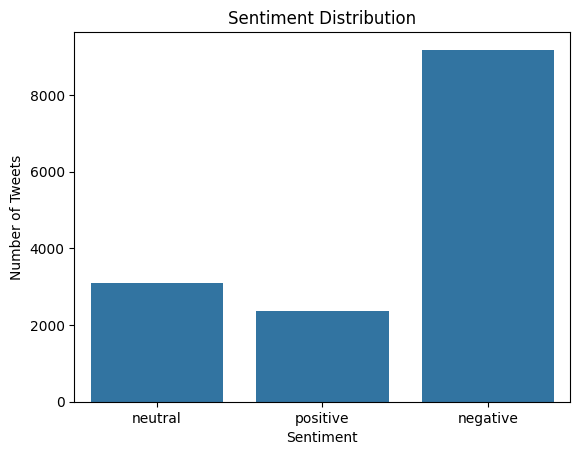

In [ ]:
plt.figure()
sns.countplot(x=data['airline_sentiment'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

Sentiment Percentage Pie Chart ->

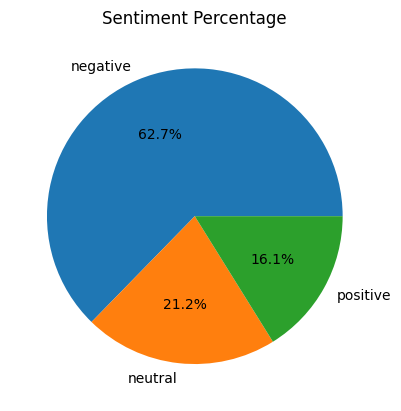

In [ ]:
sentiment_counts = data['airline_sentiment'].value_counts()

plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Percentage")
plt.show()

Airline Wise Tweet Count ->

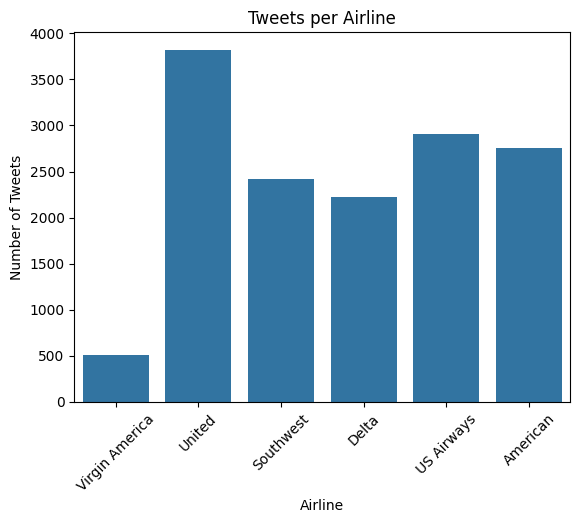

In [ ]:
plt.figure()
sns.countplot(x=data['airline'])
plt.title("Tweets per Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

Airline vs Sentiment Graph ->

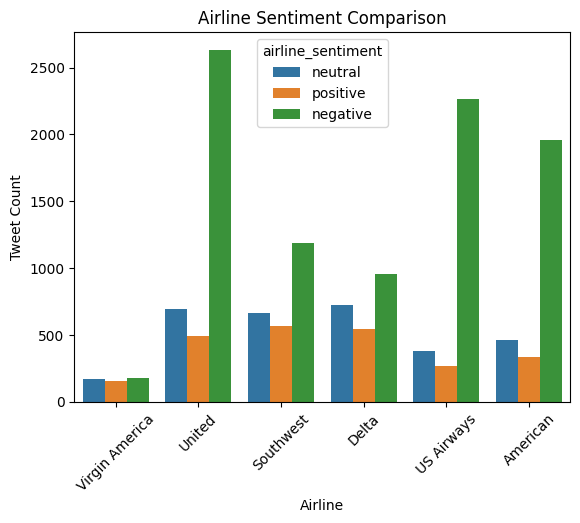

In [ ]:
plt.figure()
sns.countplot(data=data, x='airline', hue='airline_sentiment')
plt.title("Airline Sentiment Comparison")
plt.xlabel("Airline")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)
plt.show()

Sentiment Classification Model ->

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predictions ->

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.81      0.94      0.87      1889
     neutral       0.68      0.46      0.54       580
    positive       0.81      0.60      0.69       459

    accuracy                           0.79      2928
   macro avg       0.77      0.67      0.70      2928
weighted avg       0.78      0.79      0.78      2928



Confusion Matrix Graph ->

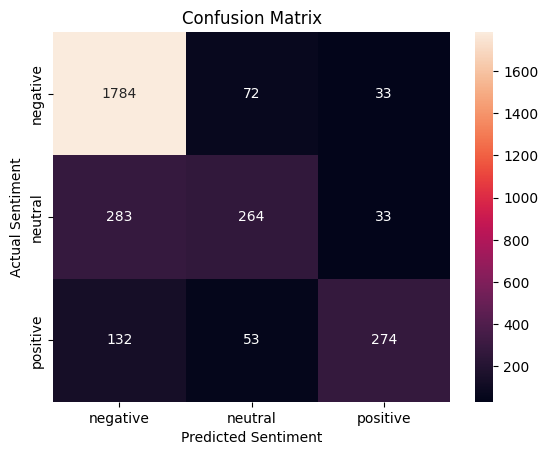

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")
plt.show()

Conclusionary Analysis Code ->

In [18]:
# Calculate prediction accuracy
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

# Compare actual vs predicted sentiment counts
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual Sentiment Distribution:")
print(result["Actual"].value_counts())

print("\nPredicted Sentiment Distribution:")
print(result["Predicted"].value_counts())

# Simple interpretation of dominant sentiment
dominant_sentiment = data['airline_sentiment'].value_counts().idxmax()


Model Accuracy: 0.7930327868852459

Actual Sentiment Distribution:
Actual
negative    1889
neutral      580
positive     459
Name: count, dtype: int64

Predicted Sentiment Distribution:
Predicted
negative    2199
neutral      389
positive     340
Name: count, dtype: int64


Conclusion

The analysis shows that most airline-related tweets express negative sentiment. The machine learning model successfully classifies tweets into positive, neutral, and negative categories, helping identify customer opinion patterns.